# 05 — Attribution

How each model class explains the same inputs, and why the explanations differ.

| Method | Use |
|---|---|
| Permutation importance | comparison **across** models — the same procedure for all three |
| Drop-column importance | refit without each feature — what the model cannot replace |
| Grouped permutation | whole feature families shuffled together — robust to correlated lags |
| SHAP (interventional) | explanation **within** each model — one estimator for all three |

Attribution is computed out-of-fold on the five-fold TimeSeriesSplit of the training
period and repeated over five seeds, so disagreement between models can be compared
with each model's disagreement with itself. The test period is used only in the last
section, to examine explanations during the 2022–2024 drought.

Input: `data/processed/features_*.csv`, `results/04_best_params.json`
Output: `results/05_*`

In [1]:
import json
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from scipy.stats import spearmanr, weightedtau
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

BRANCHES = ["original", "seasonal", "trend"]
MODEL_NAMES = ["XGBoost", "RandomForest", "Ridge"]
SEEDS = range(5)
CV = TimeSeriesSplit(n_splits=5)

BASE = {"XGBoost": XGBRegressor(n_jobs=1),
        "RandomForest": RandomForestRegressor(n_jobs=-1),
        "Ridge": make_pipeline(StandardScaler(), Ridge())}
params = json.load(open("../results/04_best_params.json"))


def make_model(b, name, seed):
    est = clone(BASE[name]).set_params(**params[f"{b}|{name}"])
    if name != "Ridge":
        est.set_params(random_state=seed)
    return est


def family(f):
    if f == "noise_probe":
        return "noise probe"
    if f.startswith("LST"):
        return "LST"
    if f.startswith("SPEI"):
        return "drought"
    if f.startswith("month"):
        return "calendar"
    return "own history"


short = lambda f: f.replace("NDVI_", "").replace("NDVI", "")

train, test = {}, {}
for b in BRANCHES:
    df = pd.read_csv(f"../data/processed/features_{b}.csv", index_col="date", parse_dates=True)
    X, y, tr = df.drop(columns=["target", "split"]), df["target"], df["split"] == "train"
    train[b], test[b] = (X[tr], y[tr]), (X[~tr], y[~tr])
    print(f"{b:9s} train {train[b][0].shape}  test {test[b][0].shape}")

original  train (238, 12)  test (36, 12)
seasonal  train (238, 15)  test (36, 15)
trend     train (238, 6)  test (36, 6)


## Permutation importance

Increase in mean squared error when one feature is shuffled, averaged over ten
shuffles and the five validation folds.

In [2]:
def oof_permutation(b, name, seed):
    X, y = train[b]
    folds = []
    for fit_idx, val_idx in CV.split(X):
        model = make_model(b, name, seed).fit(X.iloc[fit_idx], y.iloc[fit_idx])
        r = permutation_importance(model, X.iloc[val_idx], y.iloc[val_idx],
                                   n_repeats=10, random_state=seed,
                                   scoring="neg_mean_squared_error")
        folds.append(r.importances_mean)
    return pd.Series(np.mean(folds, axis=0), index=X.columns)


perm = pd.concat({(b, name, seed): oof_permutation(b, name, seed)
                  for b in BRANCHES for name in MODEL_NAMES for seed in SEEDS},
                 names=["branch", "model", "seed", "feature"]).rename("importance")
perm_mean = perm.groupby(["branch", "model", "feature"]).mean()

for b in BRANCHES:
    t = perm_mean[b].unstack("model")[MODEL_NAMES]
    t = t.loc[t.mean(axis=1).sort_values(ascending=False).index]
    print(f"\n{b}  (increase in MSE, x1e4)")
    print((t * 1e4).round(2).to_string())


original  (increase in MSE, x1e4)
model        XGBoost  RandomForest  Ridge
feature                                  
LST_lag1      178.98        124.95  17.44
NDVI_lag1      35.71         21.75  92.06
NDVI_lag24     14.51         24.65  38.25
NDVI_lag12      1.81          7.94  26.23
NDVI_lag3       0.68          0.35  10.68
NDVI_lag14      0.80          0.57   8.25
NDVI_lag18      0.70          4.53   3.63
NDVI_lag11      4.51          2.92   0.94
NDVI_lag23      2.28          2.02   3.86
SPEI_6_lag1     1.48          0.83   4.79
month_cos       2.26          1.69   2.06
noise_probe    -0.17         -0.09   0.56

seasonal  (increase in MSE, x1e4)
model           XGBoost  RandomForest  Ridge
feature                                     
LST_S_lag1       107.49         85.30  18.35
NDVI_S_lag24      35.35         36.30  65.53
NDVI_S_lag1       20.22         13.25  68.69
NDVI_S_lag12       5.08          9.59  19.63
NDVI_S_lag14       1.08          0.52  21.69
NDVI_S_lag18       4.74    

## Drop-column importance

Each feature removed in turn and the model refitted, scored out-of-fold and averaged
over the five seeds. The refitted model can reroute through correlated features, so
this measures what it cannot replace.

In [3]:
def oof_mse(b, name, cols, seed):
    X, y = train[b]
    X = X[cols]
    errs = [np.mean((y.iloc[v] - make_model(b, name, seed).fit(X.iloc[f], y.iloc[f])
                                 .predict(X.iloc[v])) ** 2)
            for f, v in CV.split(X)]
    return np.mean(errs)


drop = {}
for b in BRANCHES:
    cols = list(train[b][0].columns)
    for name in MODEL_NAMES:
        seeds = [0] if name == "Ridge" else SEEDS          # Ridge is deterministic
        full = np.mean([oof_mse(b, name, cols, s) for s in seeds])
        for f in cols:
            reduced = np.mean([oof_mse(b, name, [c for c in cols if c != f], s) for s in seeds])
            drop[(b, name, f)] = reduced / full - 1

drop = pd.Series(drop, name="drop").rename_axis(["branch", "model", "feature"])

for b in BRANCHES:
    t = drop[b].unstack("model")[MODEL_NAMES]
    t = t.loc[t.mean(axis=1).sort_values(ascending=False).index]
    print(f"\n{b}  (% increase in out-of-fold MSE when the feature is removed)")
    print((100 * t).round(1).to_string())


original  (% increase in out-of-fold MSE when the feature is removed)
model        XGBoost  RandomForest  Ridge
feature                                  
NDVI_lag1       23.4          23.8   41.6
LST_lag1        33.8          30.3    2.1
NDVI_lag14       1.7           0.6    3.5
SPEI_6_lag1      0.7           1.4    1.4
NDVI_lag11       3.2           0.5   -0.8
NDVI_lag23      -1.5           1.8    2.0
month_cos        1.2           2.2   -2.9
noise_probe      0.1          -1.4    0.6
NDVI_lag12       0.4          -3.9    2.8
NDVI_lag18      -0.4           1.2   -1.9
NDVI_lag3       -1.0           0.2   -1.3
NDVI_lag24      -2.3           0.7   -1.8

seasonal  (% increase in out-of-fold MSE when the feature is removed)
model           XGBoost  RandomForest  Ridge
feature                                     
NDVI_S_lag1        22.2          13.3   26.9
LST_S_lag1          7.2          17.0    3.7
NDVI_S_lag24        4.6           6.0    9.5
NDVI_S_lag14       -0.4           0.8   11.6


## SHAP

Interventional SHAP for all three models, estimated by the same model-agnostic
permutation explainer against one background of 100 training months, so the three
explanations share one estimator. (TreeExplainer's interventional mode does not
support XGBoost 3 models.) For Ridge the exact value is `coef × (z − mean z)`, and the
estimate is checked against it.

In [4]:
background = {b: train[b][0].sample(100, random_state=0) for b in BRANCHES}


def shap_values(b, name, seed=0):
    X, y = train[b]
    model = make_model(b, name, seed).fit(X, y)
    masker = shap.maskers.Independent(background[b], max_samples=len(background[b]))
    explainer = shap.PermutationExplainer(model.predict, masker, seed=0)
    return explainer(X, silent=True).values, model


shap_raw, shap_mean, checks = {}, {}, []
for b in BRANCHES:
    X = train[b][0]
    for name in MODEL_NAMES:
        sv, model = shap_values(b, name)
        shap_raw[(b, name)] = sv
        shap_mean[(b, name)] = pd.Series(np.abs(sv).mean(axis=0), index=X.columns)
        if name == "Ridge":
            scaler, ridge = model.named_steps["standardscaler"], model.named_steps["ridge"]
            exact = (scaler.transform(X) - scaler.transform(background[b]).mean(axis=0)) * ridge.coef_
            checks.append(dict(branch=b, max_abs_diff=np.abs(exact - sv).max(),
                               rho_coef_shap=spearmanr(np.abs(ridge.coef_),
                                                       np.abs(sv).mean(axis=0)).statistic))

shap_mean = pd.concat(shap_mean, names=["branch", "model", "feature"]).rename("shap")
print("Ridge checks"); print(pd.DataFrame(checks).round(4).to_string(index=False))

print(f"\n{'branch':9s} {'model':12s} Spearman(SHAP, permutation)")
for b in BRANCHES:
    for name in MODEL_NAMES:
        print(f"{b:9s} {name:12s} {spearmanr(shap_mean[b][name], perm_mean[b][name]).statistic:+.2f}")

Ridge checks
  branch  max_abs_diff  rho_coef_shap
original           0.0            1.0
seasonal           0.0            1.0
   trend           0.0            1.0

branch    model        Spearman(SHAP, permutation)
original  XGBoost      +0.47
original  RandomForest +0.54
original  Ridge        +0.60
seasonal  XGBoost      +0.52
seasonal  RandomForest +0.61
seasonal  Ridge        +0.84
trend     XGBoost      -0.03
trend     RandomForest +0.83
trend     Ridge        +0.37


### SHAP summary plots

One panel per model. Each dot is a training month; position is the feature's SHAP
value, colour its value.

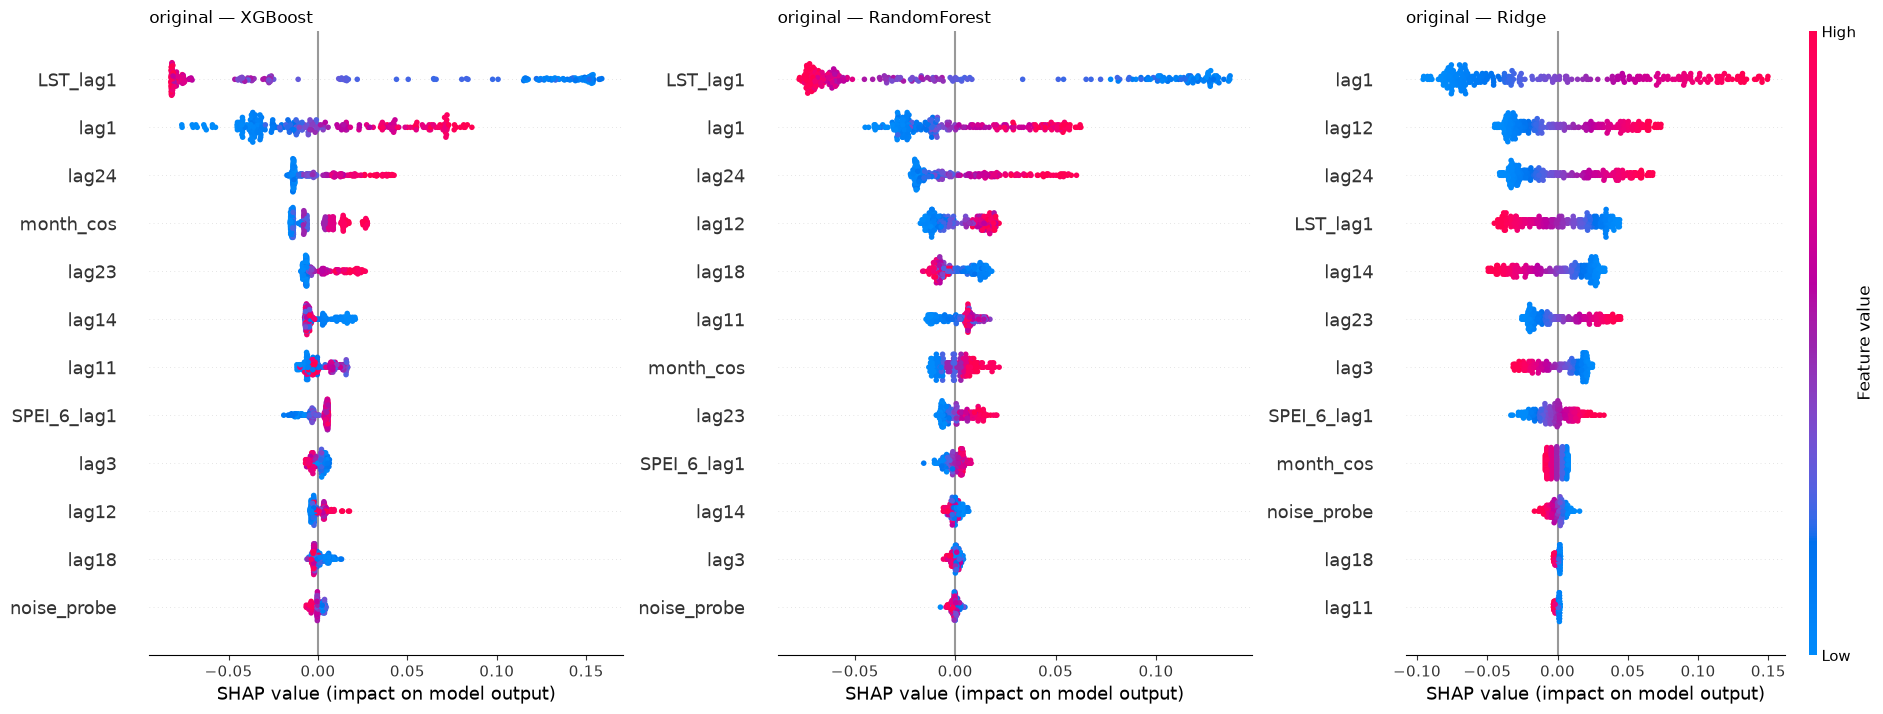

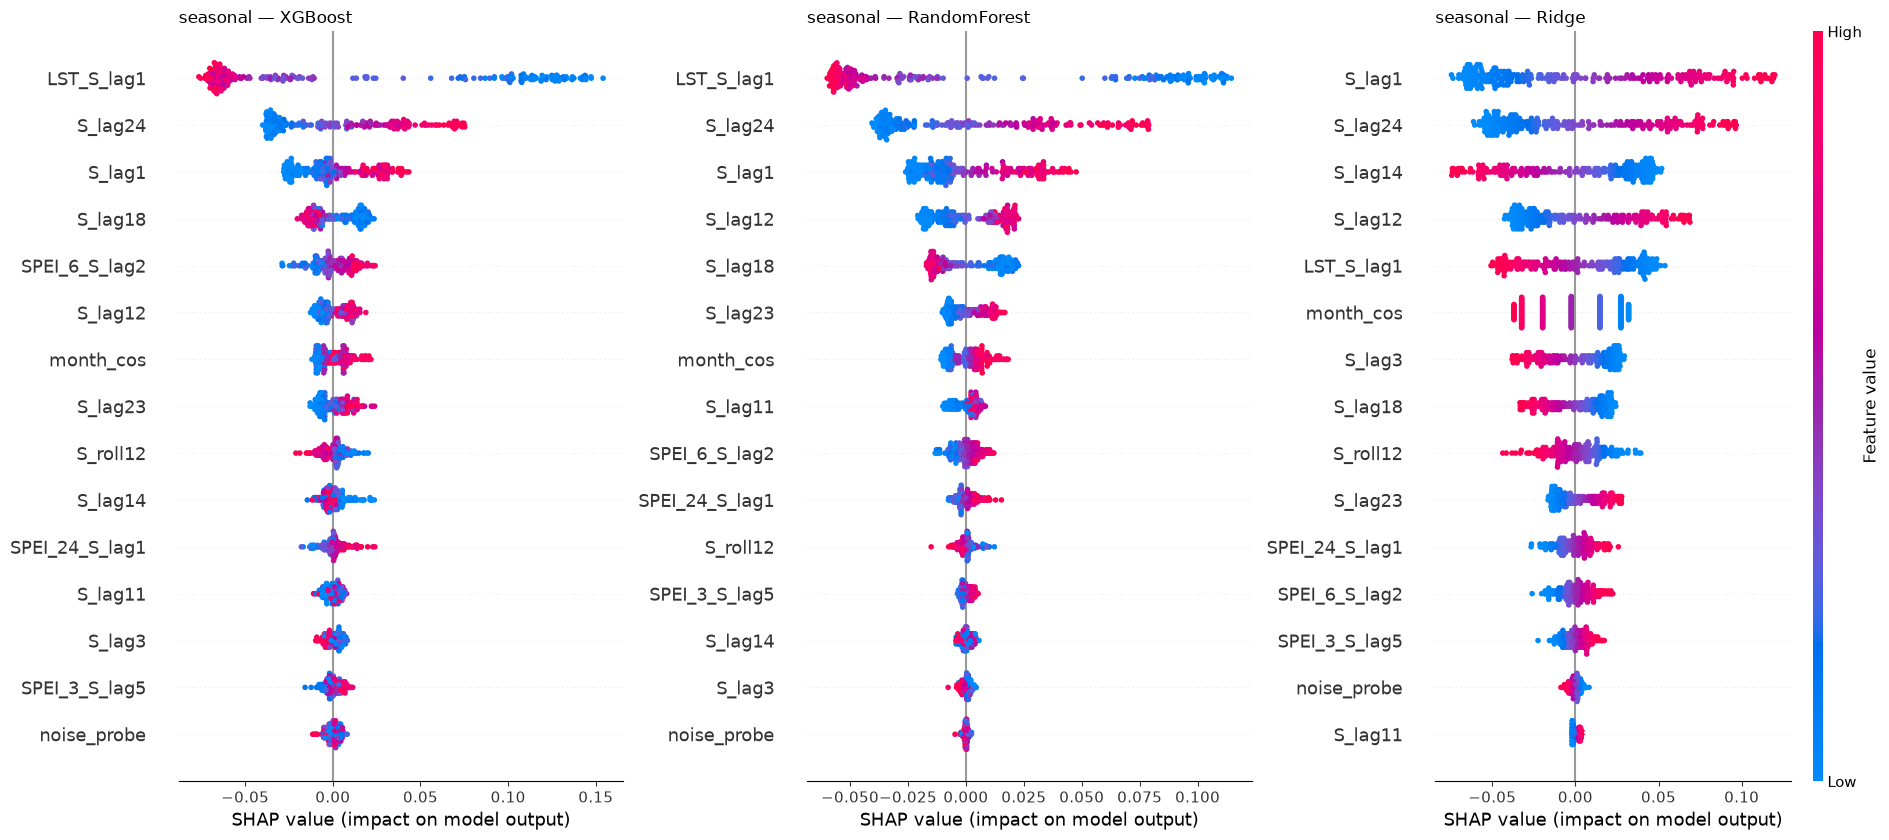

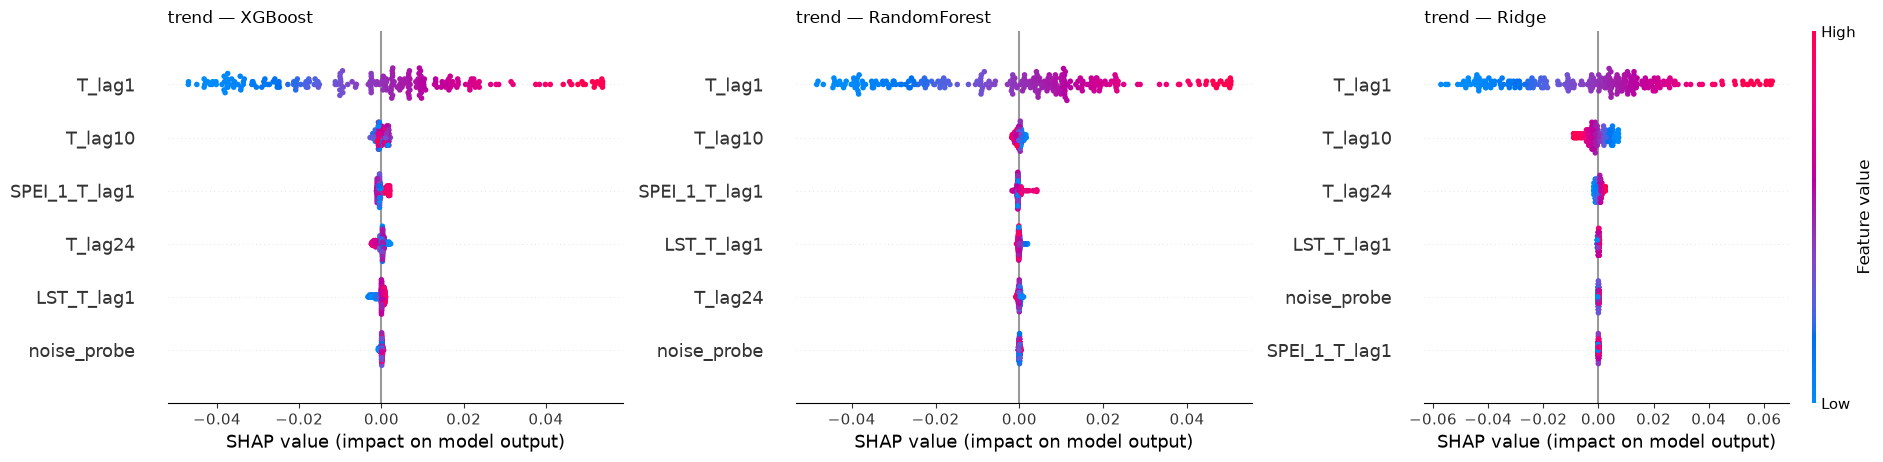

In [5]:
for b in BRANCHES:
    X = train[b][0]
    fig = plt.figure(figsize=(19, 0.42 * X.shape[1] + 2.2))
    for i, name in enumerate(MODEL_NAMES, start=1):
        ax = fig.add_subplot(1, 3, i)
        expl = shap.Explanation(shap_raw[(b, name)], data=X.to_numpy(),
                                feature_names=[short(f) for f in X.columns])
        shap.plots.beeswarm(expl, max_display=X.shape[1], show=False, ax=ax,
                            plot_size=None, color_bar=(i == 3))
        ax.set_title(f"{b} — {name}", loc="left")
    fig.tight_layout()
    fig.savefig(f"../figures/05_shap_{b}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Agreement between models

Two measures, each computed for every pair of seed runs:

- **weighted Kendall's τ** (Vigna, 2015) — rank agreement weighted towards the top of
  both rankings, so the ordering of near-zero features counts little
- **allocation distance** — the share of total importance that would have to move to
  turn one model's allocation into the other's (0 identical, 1 disjoint)

Within-model pairs (same model, different seeds) give the null range. A between-model
pair is **separable** when its whole range lies outside both models' within ranges.

In [6]:
def shares(s):
    s = s.clip(lower=0)
    return s / s.sum()


def wtau(a, b):
    return weightedtau(a.to_numpy(), b.to_numpy()).statistic


def alloc(a, b):
    return 0.5 * np.abs(shares(a) - shares(b)).sum()


runs = {(b, m): [perm[b][m][s] for s in SEEDS] for b in BRANCHES for m in MODEL_NAMES}

rows, within = [], {}
for b in BRANCHES:
    for m in MODEL_NAMES:
        pairs = list(combinations(runs[(b, m)], 2))
        t, a = [wtau(x, y) for x, y in pairs], [alloc(x, y) for x, y in pairs]
        within[(b, m)] = (min(t), max(a))
        rows.append(dict(branch=b, pair=f"{m} vs itself", tau=np.median(t), tau_lo=min(t),
                         tau_hi=max(t), dist=np.median(a), dist_lo=min(a), dist_hi=max(a)))
    for m1, m2 in combinations(MODEL_NAMES, 2):
        pairs = [(x, y) for x in runs[(b, m1)] for y in runs[(b, m2)]]
        t, a = [wtau(x, y) for x, y in pairs], [alloc(x, y) for x, y in pairs]
        separable = (max(t) < min(within[(b, m1)][0], within[(b, m2)][0])
                     and min(a) > max(within[(b, m1)][1], within[(b, m2)][1]))
        rows.append(dict(branch=b, pair=f"{m1} vs {m2}", tau=np.median(t), tau_lo=min(t),
                         tau_hi=max(t), dist=np.median(a), dist_lo=min(a), dist_hi=max(a),
                         separable=separable))

agreement = pd.DataFrame(rows)
print(agreement.round(2).to_string(index=False))

  branch                    pair  tau  tau_lo  tau_hi  dist  dist_lo  dist_hi separable
original       XGBoost vs itself 0.95    0.89    0.96  0.02     0.01     0.03       NaN
original  RandomForest vs itself 1.00    0.98    1.00  0.02     0.01     0.03       NaN
original         Ridge vs itself 1.00    1.00    1.00  0.01     0.01     0.02       NaN
original XGBoost vs RandomForest 0.78    0.75    0.82  0.13     0.11     0.14      True
original        XGBoost vs Ridge 0.46    0.43    0.48  0.67     0.65     0.68      True
original   RandomForest vs Ridge 0.45    0.44    0.45  0.59     0.56     0.60      True
seasonal       XGBoost vs itself 0.83    0.74    0.90  0.18     0.07     0.26       NaN
seasonal  RandomForest vs itself 0.98    0.97    1.00  0.03     0.02     0.05       NaN
seasonal         Ridge vs itself 0.99    0.98    1.00  0.01     0.01     0.02       NaN
seasonal XGBoost vs RandomForest 0.89    0.80    0.94  0.15     0.08     0.21     False
seasonal        XGBoost vs Ridge

In [7]:
def top_k(s, k=3):
    return set(s.sort_values(ascending=False).index[:k])


print("top-3 features by permutation importance\n")
for b in BRANCHES:
    print(b)
    for name in MODEL_NAMES:
        print(f"  {name:12s} {sorted(short(f) for f in top_k(perm_mean[b][name]))}")
    for m1, m2 in combinations(MODEL_NAMES, 2):
        n = len(top_k(perm_mean[b][m1]) & top_k(perm_mean[b][m2]))
        print(f"    {m1} & {m2}: {n}/3 shared")

top-3 features by permutation importance

original
  XGBoost      ['LST_lag1', 'lag1', 'lag24']
  RandomForest ['LST_lag1', 'lag1', 'lag24']
  Ridge        ['lag1', 'lag12', 'lag24']
    XGBoost & RandomForest: 3/3 shared
    XGBoost & Ridge: 2/3 shared
    RandomForest & Ridge: 2/3 shared
seasonal
  XGBoost      ['LST_S_lag1', 'S_lag1', 'S_lag24']
  RandomForest ['LST_S_lag1', 'S_lag1', 'S_lag24']
  Ridge        ['S_lag1', 'S_lag14', 'S_lag24']
    XGBoost & RandomForest: 3/3 shared
    XGBoost & Ridge: 2/3 shared
    RandomForest & Ridge: 2/3 shared
trend
  XGBoost      ['SPEI_1_T_lag1', 'T_lag1', 'T_lag24']
  RandomForest ['LST_T_lag1', 'T_lag1', 'T_lag24']
  Ridge        ['T_lag1', 'T_lag10', 'T_lag24']
    XGBoost & RandomForest: 2/3 shared
    XGBoost & Ridge: 2/3 shared
    RandomForest & Ridge: 2/3 shared


## Probes

`noise_probe` is random, so a feature ranked at or below it is indistinguishable from
noise. The LST lag-1 control carried no *linear* incremental evidence in notebook 03.

In [8]:
rows = []
for b in BRANCHES:
    for name in MODEL_NAMES:
        s = perm_mean[b][name].sort_values(ascending=False)
        lst = [f for f in s.index if f.startswith("LST")][0]
        rows.append(dict(branch=b, model=name, n_features=len(s),
                         noise_rank=s.index.get_loc("noise_probe") + 1,
                         lst_rank=s.index.get_loc(lst) + 1,
                         lst_share=shares(s)[lst],
                         below_noise=", ".join(short(f) for f in
                                               s.index[s.index.get_loc("noise_probe") + 1:])))
probes = pd.DataFrame(rows)
print(probes.assign(lst_share=probes.lst_share.round(3)).to_string(index=False))

  branch        model  n_features  noise_rank  lst_rank  lst_share         below_noise
original      XGBoost          12          12         1      0.734                    
original RandomForest          12          12         1      0.650                    
original        Ridge          12          12         4      0.084                    
seasonal      XGBoost          15          15         1      0.575                    
seasonal RandomForest          15          15         1      0.534                    
seasonal        Ridge          15          15         5      0.078                    
   trend      XGBoost           6           4         6      0.000 T_lag10, LST_T_lag1
   trend RandomForest           6           6         3      0.003                    
   trend        Ridge           6           6         4      0.000                    


## Family importance

Each family shuffled as a block, with one row permutation applied to all its columns,
so correlated lags cannot cover for one another.

In [9]:
def family_permutation(model, X, y, rng, n_repeats=10):
    fams = pd.Series({c: family(c) for c in X.columns})
    base = np.mean((y - model.predict(X)) ** 2)
    out = {}
    for fam, cols in fams.groupby(fams).groups.items():
        cols, inc = list(cols), []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = X[cols].to_numpy()[rng.permutation(len(X))]
            inc.append(np.mean((y - model.predict(Xp)) ** 2) - base)
        out[fam] = np.mean(inc)
    return pd.Series(out)


def oof_family(b, name, seed):
    X, y = train[b]
    rng = np.random.default_rng(seed)
    folds = [family_permutation(make_model(b, name, seed).fit(X.iloc[f], y.iloc[f]),
                                X.iloc[v], y.iloc[v], rng)
             for f, v in CV.split(X)]
    return pd.concat(folds, axis=1).mean(axis=1)


fam = pd.concat({(b, name, seed): oof_family(b, name, seed)
                 for b in BRANCHES for name in MODEL_NAMES for seed in SEEDS},
                names=["branch", "model", "seed", "family"])
fam_mean = fam.groupby(["branch", "model", "family"]).mean()
fam_share = fam_mean.clip(lower=0).groupby(["branch", "model"]).transform(lambda s: s / s.sum())
print(fam_share.unstack("model")[MODEL_NAMES].round(3).to_string())

model                 XGBoost  RandomForest  Ridge
branch   family                                   
original LST            0.607         0.445  0.045
         calendar       0.007         0.006  0.005
         drought        0.006         0.003  0.012
         noise probe    0.000         0.000  0.002
         own history    0.380         0.547  0.936
seasonal LST            0.375         0.304  0.040
         calendar       0.006         0.005  0.025
         drought        0.016         0.010  0.019
         noise probe    0.001         0.000  0.000
         own history    0.603         0.681  0.915
trend    LST            0.000         0.003  0.001
         drought        0.001         0.003  0.000
         noise probe    0.000         0.000  0.000
         own history    0.998         0.993  0.999


## Why the trees need LST

Lagged LST is split into its training-period **climatology** for the calendar month,
which carries only the season, and its **anomaly**, which carries only the departure
of that month from normal. Each model is refitted with LST as used, without LST, with
the climatology only and with the anomaly only. Climatologies are computed inside each
training fold.

If the climatology alone restores what removing LST costs, the trees use LST as a
season clock rather than as information about heat.

In [10]:
VARIANTS = ["as used", "no LST", "climatology only", "anomaly only"]


def lst_cv_mse(b, name, seed, variant):
    X, y = train[b]
    c = [f for f in X.columns if f.startswith("LST")][0]
    month = pd.Series((X.index - pd.DateOffset(months=1)).month, index=X.index)
    errs = []
    for f, v in CV.split(X):
        Xf, Xv = X.iloc[f].copy(), X.iloc[v].copy()
        clim = Xf[c].groupby(month.iloc[f]).mean()
        cf, cv_ = month.iloc[f].map(clim).to_numpy(), month.iloc[v].map(clim).to_numpy()
        if variant == "no LST":
            Xf, Xv = Xf.drop(columns=c), Xv.drop(columns=c)
        elif variant == "climatology only":
            Xf[c], Xv[c] = cf, cv_
        elif variant == "anomaly only":
            Xf[c], Xv[c] = Xf[c] - cf, Xv[c] - cv_
        model = make_model(b, name, seed).fit(Xf, y.iloc[f])
        errs.append(np.mean((y.iloc[v] - model.predict(Xv)) ** 2))
    return np.mean(errs)


rows = []
for b in ["original", "seasonal"]:
    for name in MODEL_NAMES:
        seeds = [0] if name == "Ridge" else SEEDS
        mse = {v: np.mean([lst_cv_mse(b, name, s, v) for s in seeds]) for v in VARIANTS}
        rows.append(dict(branch=b, model=name,
                         **{v: 100 * (mse[v] / mse["as used"] - 1) for v in VARIANTS[1:]}))

mechanism = pd.DataFrame(rows)
print("% change in out-of-fold MSE relative to LST as used")
print(mechanism.round(1).to_string(index=False))

% change in out-of-fold MSE relative to LST as used
  branch        model  no LST  climatology only  anomaly only
original      XGBoost    33.8              23.4          29.2
original RandomForest    30.3              21.4          24.8
original        Ridge     2.1               2.5          -6.5
seasonal      XGBoost     7.2               7.9          12.8
seasonal RandomForest    17.0               4.9          14.1
seasonal        Ridge     3.7               3.0          -1.3


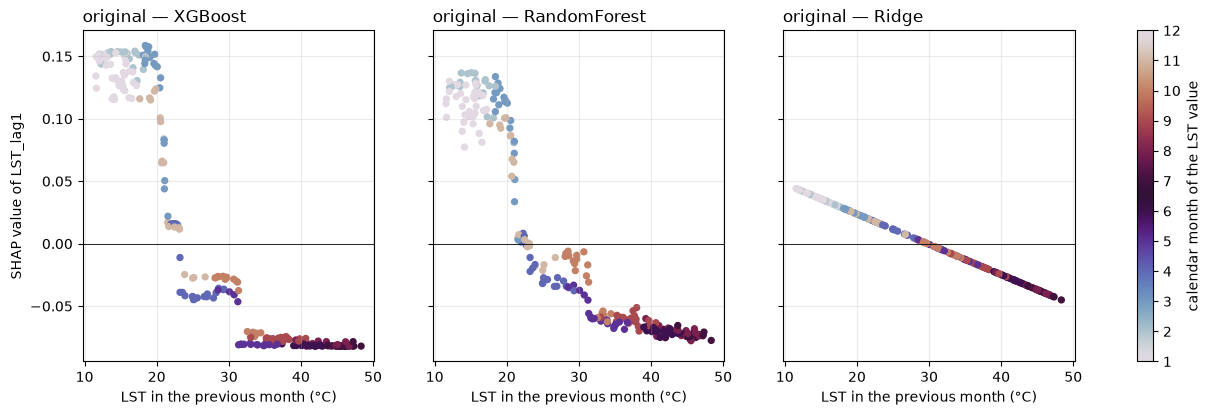

In [11]:
X = train["original"][0]
prev_month = (X.index - pd.DateOffset(months=1)).month
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for ax, name in zip(axes, MODEL_NAMES):
    j = list(X.columns).index("LST_lag1")
    sc = ax.scatter(X["LST_lag1"], shap_raw[("original", name)][:, j], c=prev_month,
                    cmap="twilight", s=18, vmin=1, vmax=12)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("LST in the previous month (°C)")
    ax.set_title(f"original — {name}", loc="left")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("SHAP value of LST_lag1")
fig.colorbar(sc, ax=axes, label="calendar month of the LST value", ticks=range(1, 13))
fig.savefig("../figures/05_lst_mechanism.png", dpi=150, bbox_inches="tight")
plt.show()

## Explanations during the 2022–2024 drought

Permutation importance recomputed on the test period, with models trained on the full
training period, and compared with the out-of-fold training importance. A low weighted
τ means a model relies on different features under drought than in the years it was
trained on.

In [12]:
rows = []
for b in BRANCHES:
    (Xtr, ytr), (Xte, yte) = train[b], test[b]
    for name in MODEL_NAMES:
        imp, famx = [], []
        for s in SEEDS:
            model = make_model(b, name, s).fit(Xtr, ytr)
            r = permutation_importance(model, Xte, yte, n_repeats=10, random_state=s,
                                       scoring="neg_mean_squared_error")
            imp.append(pd.Series(r.importances_mean, index=Xte.columns))
            famx.append(family_permutation(model, Xte, yte, np.random.default_rng(s)))
        imp, famx = pd.concat(imp, axis=1).mean(axis=1), pd.concat(famx, axis=1).mean(axis=1)
        ft, fd = shares(fam_mean[b][name]), shares(famx)
        rows.append(dict(branch=b, model=name, tau_train_vs_test=wtau(perm_mean[b][name], imp),
                         drought_train=ft.get("drought", 0), drought_test=fd.get("drought", 0),
                         LST_train=ft["LST"], LST_test=fd["LST"],
                         own_train=ft["own history"], own_test=fd["own history"]))

drought_shift = pd.DataFrame(rows)
print(drought_shift.round(3).to_string(index=False))

  branch        model  tau_train_vs_test  drought_train  drought_test  LST_train  LST_test  own_train  own_test
original      XGBoost              0.136          0.006         0.002      0.607     0.723      0.380     0.267
original RandomForest              0.256          0.003         0.002      0.445     0.498      0.547     0.500
original        Ridge              0.433          0.012         0.003      0.045     0.031      0.936     0.962
seasonal      XGBoost              0.360          0.016         0.012      0.375     0.457      0.603     0.529
seasonal RandomForest              0.345          0.010         0.004      0.304     0.361      0.681     0.634
seasonal        Ridge              0.573          0.019         0.003      0.040     0.031      0.915     0.923
   trend      XGBoost              0.103          0.001         0.001      0.000     0.001      0.998     0.997
   trend RandomForest              0.188          0.003         0.000      0.003     0.000      0.993   

## Saving

In [13]:
perm.to_csv("../results/05_permutation_by_seed.csv")
pd.concat([perm_mean, drop, shap_mean], axis=1).to_csv("../results/05_importance.csv")
agreement.to_csv("../results/05_agreement.csv", index=False)
probes.to_csv("../results/05_probes.csv", index=False)
fam_share.rename("share").to_csv("../results/05_family_shares.csv")
mechanism.to_csv("../results/05_lst_mechanism.csv", index=False)
drought_shift.to_csv("../results/05_drought_shift.csv", index=False)
print("saved")

saved
